# Exploratory Data Analysis: Olist Dataset

This notebook provides a comprehensive analysis of the Brazilian E-Commerce Public Dataset by Olist. We focus on product characteristics, categories, and order distributions to inform our semantic recommendation system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_palette("viridis")

# Base path to data
DATA_PATH = "../data/"

# Loading datasets
products = pd.read_csv(os.path.join(DATA_PATH, "olist_products_dataset.csv"))
orders = pd.read_csv(os.path.join(DATA_PATH, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(DATA_PATH, "olist_order_items_dataset.csv"))
translation = pd.read_csv(os.path.join(DATA_PATH, "product_category_name_translation.csv"))

print(f"Loaded {len(products)} products, {len(orders)} orders, and {len(items)} items.")

Loaded 32951 products, 99441 orders, and 112650 items.


## Product Data Overview

Merging products with English category translations.

In [2]:
products = products.merge(translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## Category Distribution

Visualizing top-10 most frequent product categories.

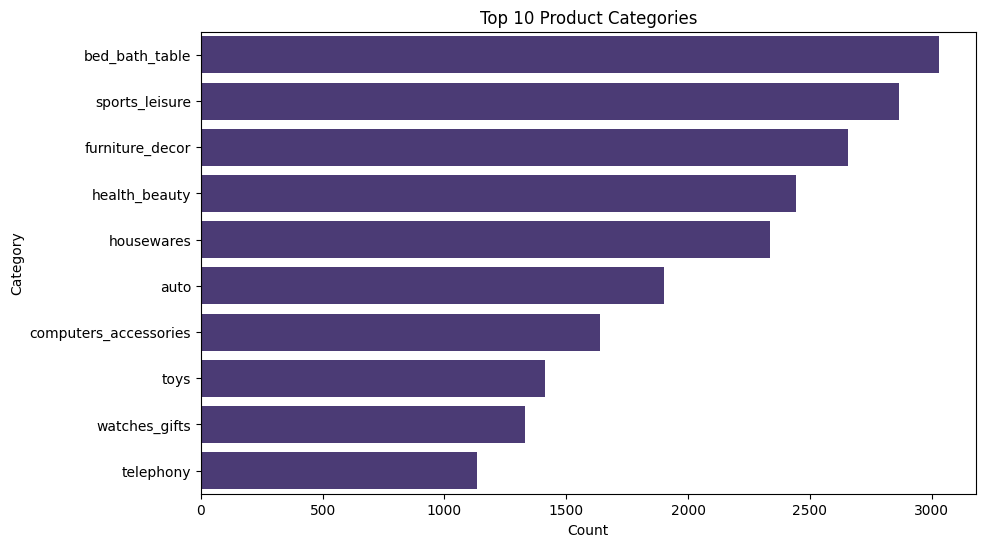

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=products, y='product_category_name_english', order=products['product_category_name_english'].value_counts().index[:10])
plt.title('Top 10 Product Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

## Numerical Analysis

Distribution of weights and dimensions.

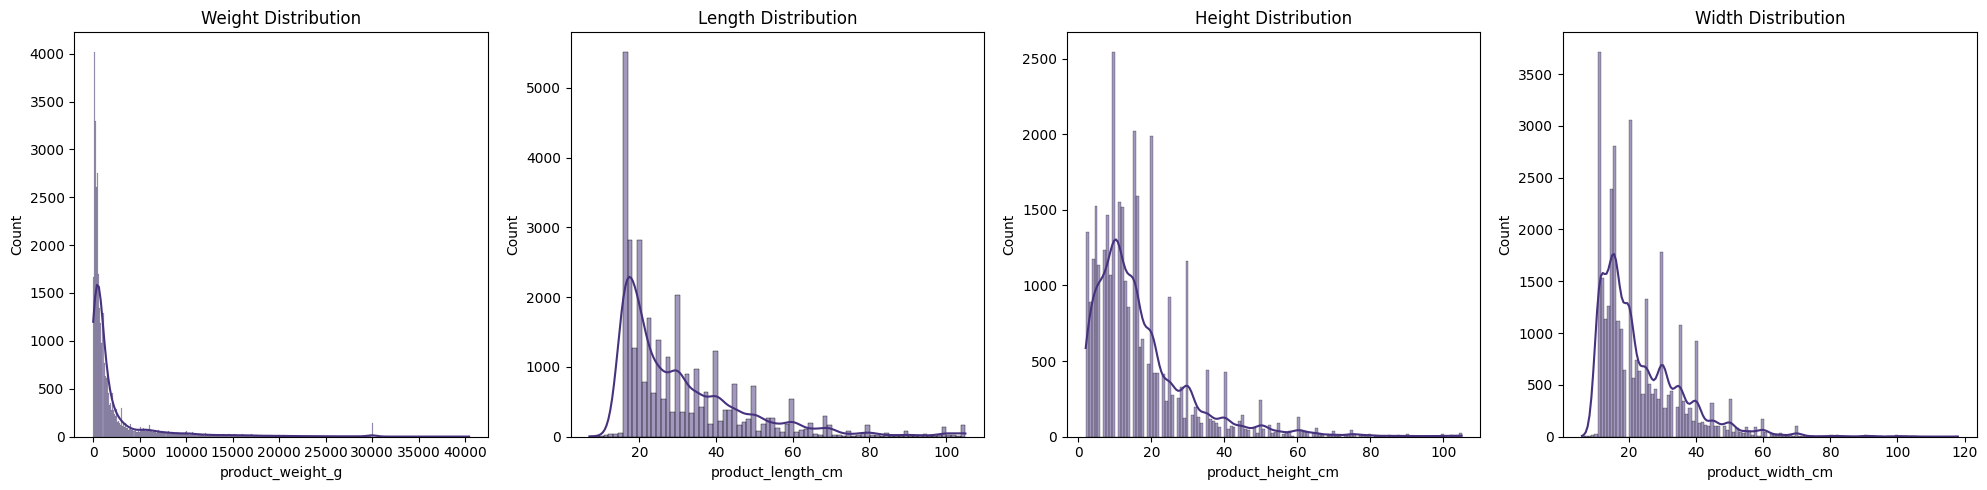

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.histplot(products['product_weight_g'], kde=True, ax=axes[0]).set_title('Weight Distribution')
sns.histplot(products['product_length_cm'], kde=True, ax=axes[1]).set_title('Length Distribution')
sns.histplot(products['product_height_cm'], kde=True, ax=axes[2]).set_title('Height Distribution')
sns.histplot(products['product_width_cm'], kde=True, ax=axes[3]).set_title('Width Distribution')
plt.tight_layout()
plt.show()

## Correlation Analysis

Relationship between dimensions.

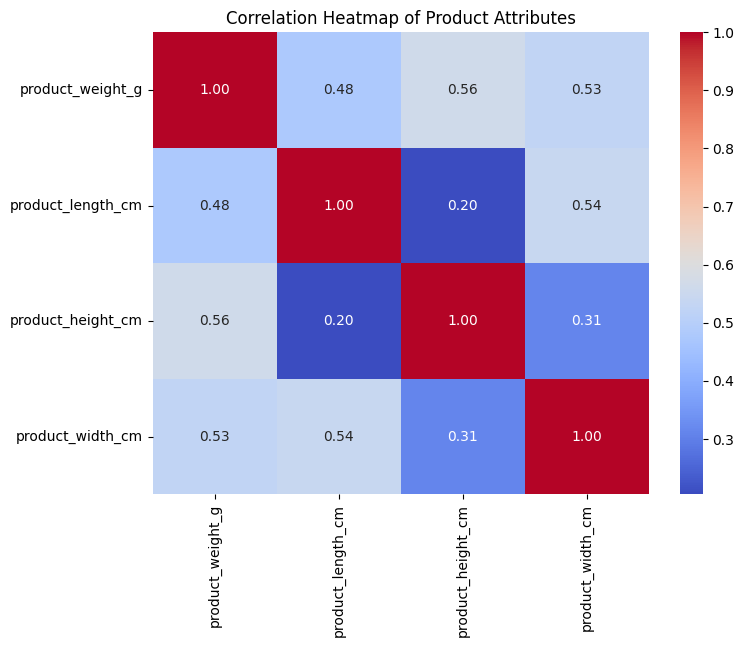

In [5]:
corr = products[["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Product Attributes")
plt.show()